# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 71     |  |
| :-------------|:-------------|
| Edzard Inia | 6519083 |
| Pim van Beers | 6542026 |

In [1]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

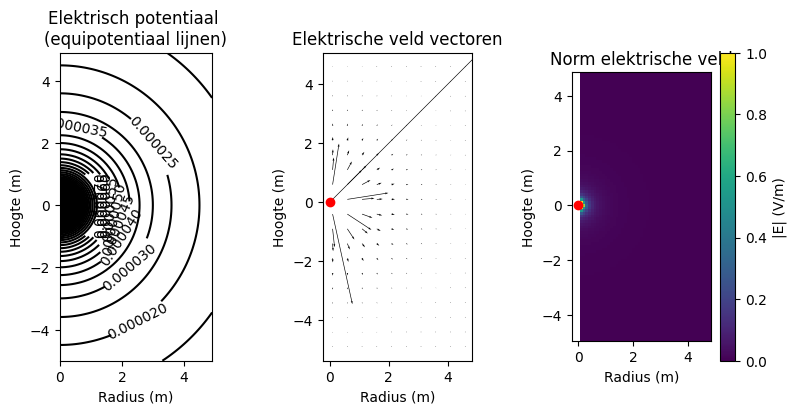

In [2]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

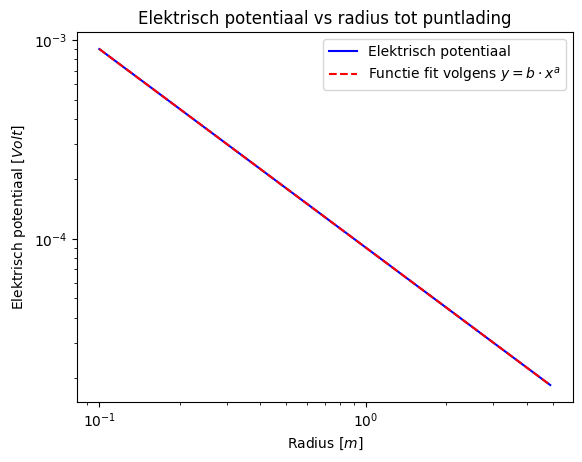

De exponent van de radius in de elektrische potentiaal functie (V(r)) is -1.0.


In [3]:
###
###Hier jouw code###
###

from scipy.optimize import curve_fit

def functie_fit(x, a, b):
    return b * (x**a) 

values, cov = curve_fit(functie_fit, r[1:], V[50,1:])

x_waardes_curve_fit = np.linspace(r[1], r[49], 1000)

plt.figure()
plt.plot(r[1:], V[50,1:], color='b', label="Elektrisch potentiaal")
plt.plot(x_waardes_curve_fit, functie_fit(x_waardes_curve_fit, values[0], values[1]), 'r--', label=r"Functie fit volgens $y = b \cdot x^{a}$")
plt.legend()
plt.xlabel(r"Radius [$m$]")
plt.ylabel(r"Elektrisch potentiaal [$Volt$]")
plt.title("Elektrisch potentiaal vs radius tot puntlading")
plt.semilogx()
plt.semilogy()
plt.show()

print(f"De exponent van de radius in de elektrische potentiaal functie (V(r)) is {round(values[0], 1)}.")

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

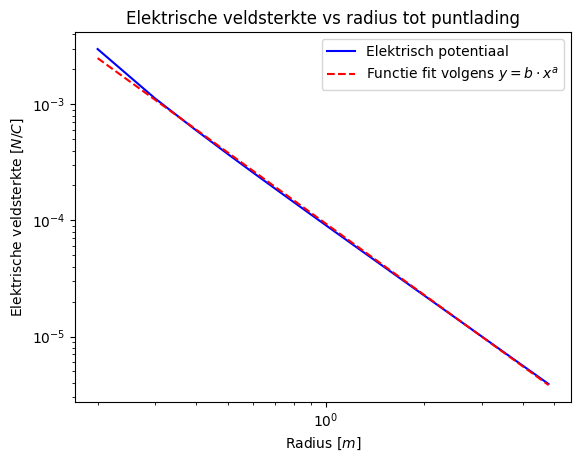

De exponent van de radius in de elektrische veldsterkte functie (E(r)) is -2.0.


In [4]:
###
###Hier jouw code###
###

from scipy.optimize import curve_fit

def functie_fit(x, a, b):
    return b * (x**a)

def functie_fit_2(x, a, b):
    return a * x + b

values, cov = curve_fit(functie_fit_2, np.log10(r_for_E[1:]), np.log10(Er[49, 1:]))

x_waardes_curve_fit = np.linspace(r_for_E[1], r_for_E[47], 1000)

plt.figure()
plt.plot(r_for_E[1:], Er[49, 1:], color='b', label="Elektrisch potentiaal")
plt.plot(x_waardes_curve_fit, functie_fit(x_waardes_curve_fit, values[0], 10**values[1]), 'r--', label=r"Functie fit volgens $y = b \cdot x^{a}$")
plt.legend()
plt.xlabel(r"Radius [$m$]")
plt.ylabel(r"Elektrische veldsterkte [$N/C$]")
plt.title("Elektrische veldsterkte vs radius tot puntlading")
plt.semilogx()
plt.semilogy()
plt.show()

print(f"De exponent van de radius in de elektrische veldsterkte functie (E(r)) is {round(values[0], 1)}.")

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [5]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

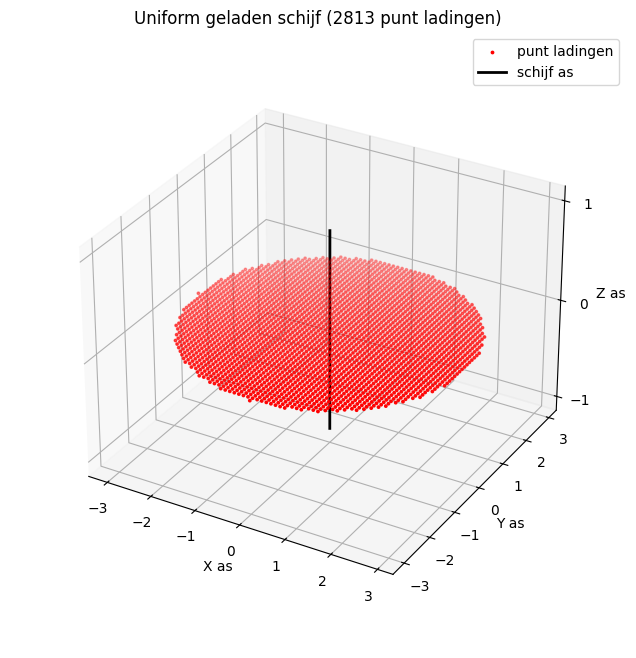

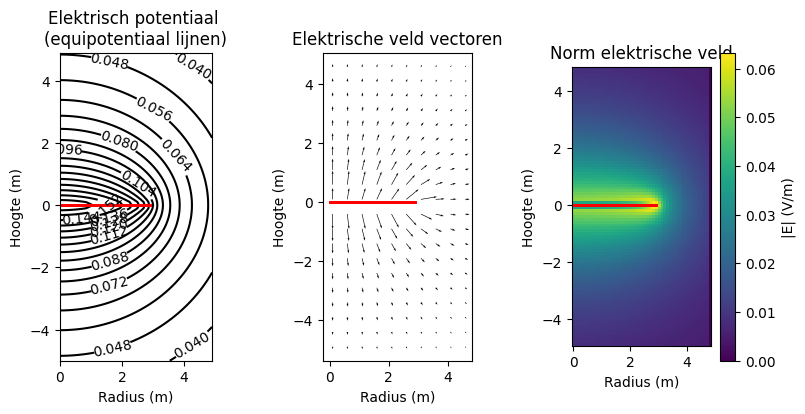

In [6]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1. De disk radius bepaalt de straal van de geladen schijf. Als deze verkleind wordt het beschikbare oppervlakte voor puntladingen ingeperkt en zal de totale lading, het potentiaal en het veld allemaal 0 naderen.
2. Grid step is de afstand tussen de puntladingen waarvoor je de potentiaal berekent. Het bepaalt de balans tussen runtime en nauwkeurigheid, een grotere nauwkeurigheid gaat ten koste van de runtime.
3. Met het aanpassen van de grid_step en de disk_radius vergroot de runtime exponentieel snel, de simulatie is al snel te complex voor onze werklaptops. De maximale waardes lijken te liggen bij grid_step = 1e-3, en disk_radius 20.


#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [7]:
###
###Hier jouw code###
###

ladingsdichtheid = (number_point_charges_on_disk * charge_one_point) / (np.pi * disk_radius**2)
print(f"Oppervlakteladingsdichtheid: σ = {ladingsdichtheid:.3e} C/m²")

Oppervlakteladingsdichtheid: σ = 9.949e-13 C/m²


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

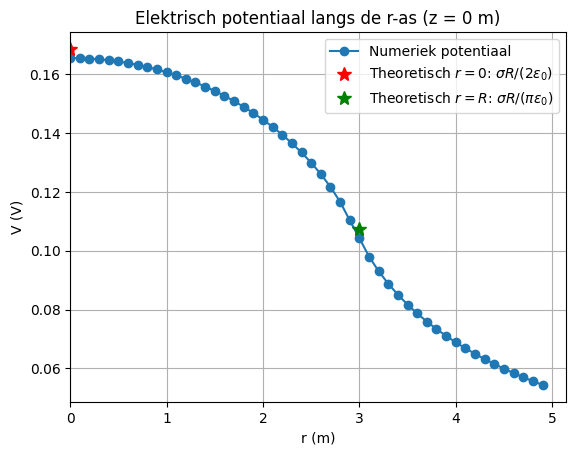

In [8]:
idx_z_zero = np.argmin(np.abs(z))

# Potentiaal op r = 0
V_0 = (ladingsdichtheid * disk_radius) / (2 * epsilon0)

# Potentiaal op r = R
V_R = (ladingsdichtheid * disk_radius) / (np.pi * epsilon0)
r_R = disk_radius

plt.figure()
plt.title("Elektrisch potentiaal langs de r-as (z = 0 m)")
plt.plot(r, V[idx_z_zero, :], "o-", label="Numeriek potentiaal")
plt.plot(0, V_0, "r*", markersize=10, label=r"Theoretisch $r=0$: $\sigma R / (2\epsilon_0)$")
plt.plot(r_R, V_R, "g*", markersize=10, label=r"Theoretisch $r=R$: $\sigma R / (\pi\epsilon_0)$")
plt.legend()
plt.xlabel("r (m)")
plt.ylabel("V (V)")
plt.xlim(left=0)
plt.grid()
plt.show()

#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


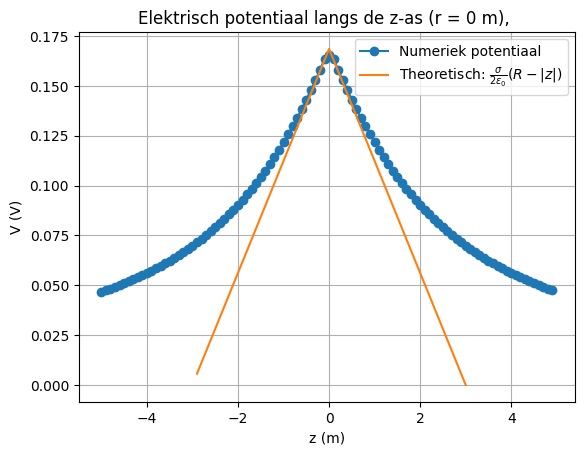

In [9]:
idx_r_zero = np.argmin(np.abs(r))
V_zas = V[:, idx_r_zero]

# Theoretische geldigheid voor |z| < R
V_theorie_z = (ladingsdichtheid / (2 * epsilon0)) * (disk_radius - np.abs(z))
mask = np.abs(z) <= disk_radius

plt.figure()
plt.title("Elektrisch potentiaal langs de z-as (r = 0 m), ")
plt.plot(z, V_zas, "o-", label="Numeriek potentiaal")
plt.plot(z[mask], V_theorie_z[mask], "-", label=r"Theoretisch: $\frac{\sigma}{2\epsilon_0}(R - |z|)$")
plt.xlabel("z (m)")
plt.ylabel("V (V)")
plt.legend()
plt.grid()
plt.savefig("figures/potentiaal_z-as.png")
plt.show()


#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

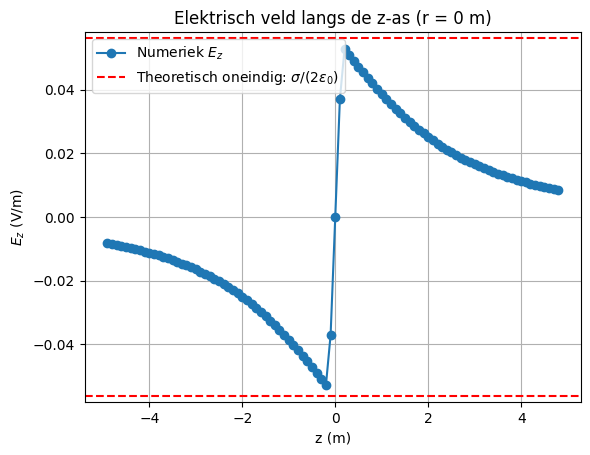

In [10]:
idx_r_zero_E = np.argmin(np.abs(r_for_E))
Ez_zas = Ez[:, idx_r_zero_E]

E_theorie = ladingsdichtheid / (2 * epsilon0)

plt.figure()
plt.title("Elektrisch veld langs de z-as (r = 0 m)")
plt.plot(z_for_E, Ez_zas, "o-", label="Numeriek $E_z$")
plt.axhline( E_theorie, color="r", linestyle="--", label=r"Theoretisch oneindig: $\sigma / (2\epsilon_0)$")
plt.axhline(-E_theorie, color="r", linestyle="--")
plt.xlabel("z (m)")
plt.ylabel("$E_z$ (V/m)")
plt.legend()
plt.grid()
plt.savefig("figures/elektrischveld_z-as.png")
plt.show()

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f

1. Het elektrische veld van de schijf benadert dat van een oneindige plaat als de afstand heel klein is zodat |z| << R. Voor de puntladingen  gedraagt de schijf zich daar alsof deze oneindig groot is.
2. De piek bij z = 0 is geen werkelijk fysisch effect maar een rekenkundige fout van de simulatie. Bovendien blijft het veld bij een werkelijke oneindige plaat constant terwijl de simulatie fluctueert. 

#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

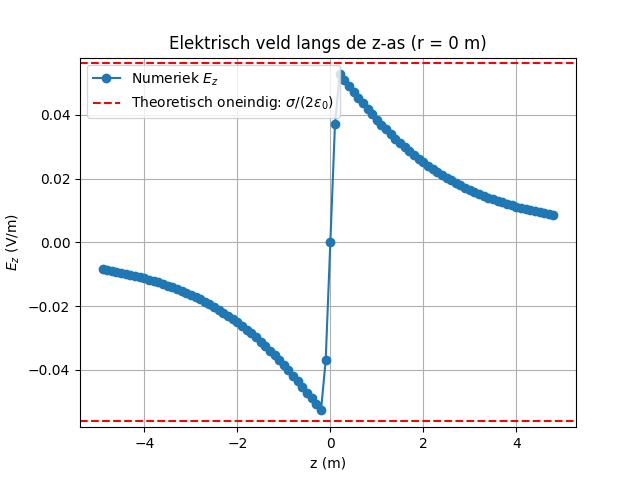

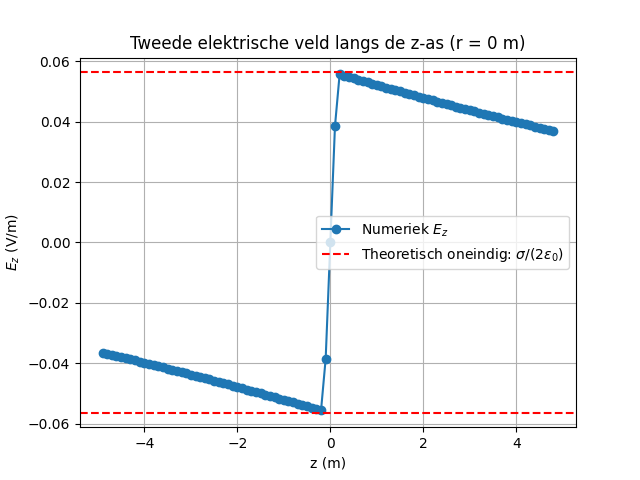

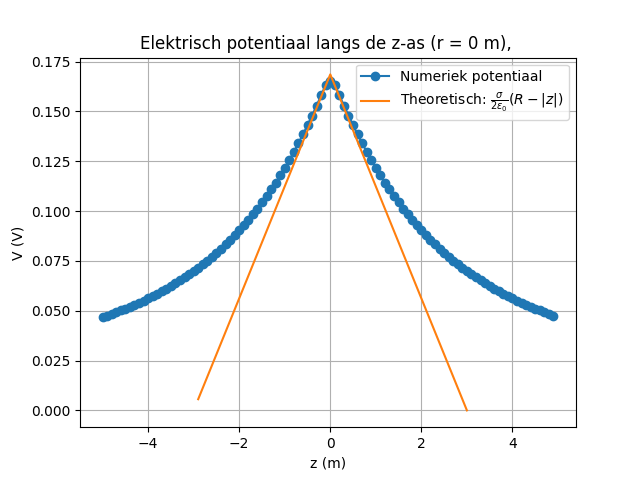

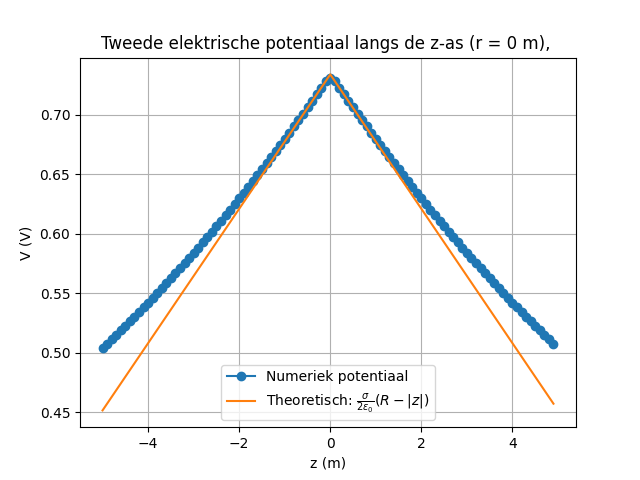

In [11]:
###
###Jouw code hier###
###
display(Image("figures/elektrischveld_z-as.png"))
display(Image("figures/tweede_elektrischveld_z-as.png"))
display(Image("figures/potentiaal_z-as.png"))
display(Image("figures/tweede_potentiaal_z-as.png"))

##### Antwoorden 2g

Bij een grotere straal (R = 13 m) blijft het numerieke veld dichter bij de theoretische waarde. De aanname |z| << R is bij een grotere schijf over een groter bereik geldig. Het potentiaal volgt bij een grotere straal de theoretische lijn verder voordat het afwijkt.

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

We willen dat $E(z) = 0.1 \cdot E_{\infty}$, dus:

$$1 - \frac{z}{\sqrt{R^2 + z^2}} = 0.1$$

$$\frac{z}{\sqrt{R^2 + z^2}} = 0.9$$

Kwadrateren en omschrijven geeft:

$$z = R\sqrt{\frac{0.81}{0.19}} \approx 2.07 R$$

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

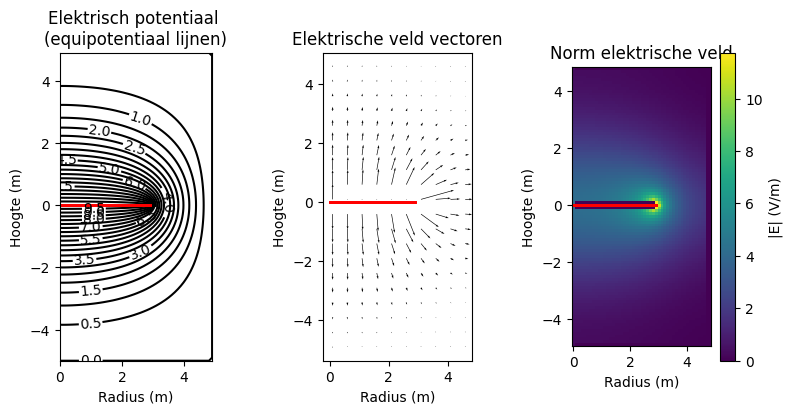

In [12]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

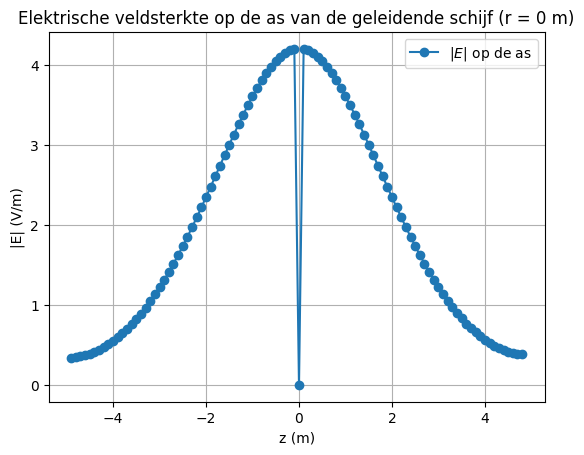

|E| bij z = 0.10 m: 4.202e+00 V/m


In [13]:
normE_zas = normE[:, idx_r_zero_E]

plt.figure()
plt.title("Elektrische veldsterkte op de as van de geleidende schijf (r = 0 m)")
plt.plot(z_for_E, normE_zas, "o-", label="$|E|$ op de as")
plt.xlabel("z (m)")
plt.ylabel("|E| (V/m)")
plt.legend()
plt.grid()
plt.show()

idx_z_dichtbij = np.argmin(np.abs(z_for_E - grid_step))
print(f"|E| bij z = {z_for_E[idx_z_dichtbij]:.2f} m: {normE_zas[idx_z_dichtbij]:.3e} V/m")

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

De formule om oppervlaktelading te benaderen in het midden van de schijf is:
$$\sigma = \epsilon_0 |E|$$

In [14]:
oppervlaktelading_midden = epsilon0 * normE_zas[idx_z_dichtbij]
print(f"Oppervlaktelading midden schijf: {oppervlaktelading_midden:.3e} C/m²")

Oppervlaktelading midden schijf: 3.720e-11 C/m²


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


Totale lading Q = 2.104e-09 C
σ geleidende schijf (r=0): 3.720e-11 C/m²
σ uniform geladen schijf:  7.441e-11 C/m²


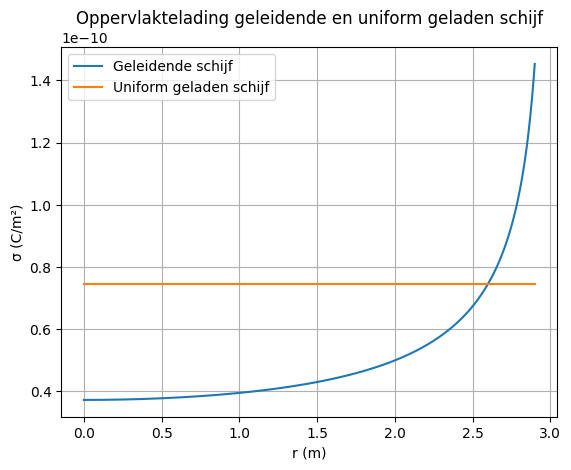

In [15]:
Q = oppervlaktelading_midden * 2 * np.pi * disk_radius**2
ladingsdichtheid_uniform = Q / (np.pi * disk_radius**2)

print(f"Totale lading Q = {Q:.3e} C")
print(f"σ geleidende schijf (r=0): {oppervlaktelading_midden:.3e} C/m²")
print(f"σ uniform geladen schijf:  {ladingsdichtheid_uniform:.3e} C/m²")

r_plot = np.linspace(0, disk_radius - grid_step, 500)
plt.figure()
plt.title("Oppervlaktelading geleidende en uniform geladen schijf")
plt.plot(r_plot, Q / (2 * np.pi * disk_radius * np.sqrt(disk_radius**2 - r_plot**2)), label="Geleidende schijf")
plt.plot(r_plot, np.full_like(r_plot, ladingsdichtheid_uniform), label="Uniform geladen schijf")
plt.xlabel("r (m)")
plt.ylabel("σ (C/m²)")
plt.legend()
plt.grid()
plt.show()

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [16]:
# Deze cel kan je gebruiken om van vraag 3c 1 tot en met 4 te beantwoorden.
idx_max = np.unravel_index(np.argmax(normE), normE.shape)
E_max = normE[idx_max]
z_max = z_for_E[idx_max[0]]
r_max = r_for_E[idx_max[1]]

verhouding = E_max / normE_zas[idx_z_dichtbij]

print(f"Maximum elektrisch veld: {E_max:.3e} V/m")
print(f"Locatie: r = {r_max:.2f} m, z = {z_max:.2f} m")
print(f"Verhouding t.o.v. midden: {verhouding:.2f}x hoger")

Maximum elektrisch veld: 1.175e+01 V/m
Locatie: r = 3.00 m, z = 0.10 m
Verhouding t.o.v. midden: 2.80x hoger


##### Antwoord 3d.5

Het maximum elektrische veld bevindt zich aan de rand van de schijf, niet in het midden. Bij een geleider hopen ladingen zich op aan de rand, waardoor de ladingsdichtheid σ(r) daar het grootst is. Omdat E = σ/ε₀ is het elektrische veld aan de rand ook het grootst.

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

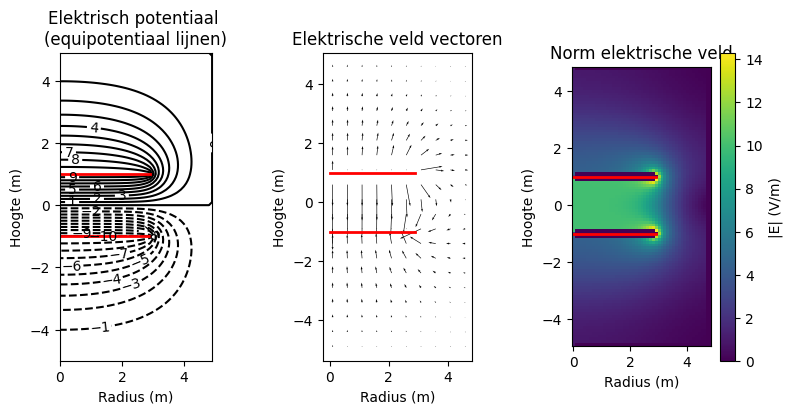

In [17]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


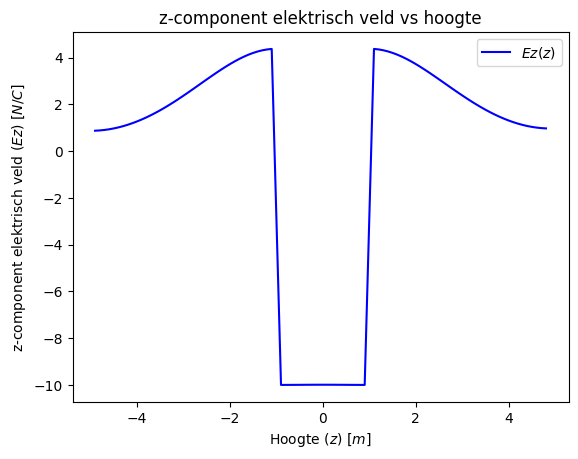

In [18]:
###
###your code here###
###

plt.figure()
plt.plot(z_for_E, Ez[:,0], color='b', label=r"$Ez(z)$")
plt.xlabel(r"Hoogte ($z$) [$m$]")
plt.ylabel(r"z-component elektrisch veld ($Ez$) [$N/C$]")
plt.legend()
plt.title("z-component elektrisch veld vs hoogte")
plt.show()

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b

*Laat in deze markdown cel je antwoorden op vraag 4b zien.*

(1) 
Bij de onderstaande afleidingen maken we de aannamen dat de platen gezien kunnen worden als twee oneindig groote platen.

De relatie tussen het elektrisch potentiaal en het elektrische veld is gegeven door:

$$\mathbf{E} = - \mathbf{\nabla} V$$

Wanneer we alleen de z-component van het elektrisch veld langs de z-as bekijken kunnen we het potentiaal differentieren naar z en krijgen we:

$$ E_{z} = -\frac{dV}{dz}(z) $$

We kijken eerst naar het elektrisch veld aan de bovenkant van de condensator (dus boven de bovenste plaat).

In dit gedeelte wordt het potentiaal gegeven door de volgende functie:

$$ V(z) = \frac{\sigma_{boven}}{2\epsilon_{0}}(1 - z) + 10 $$

Hierbij is $\sigma_{boven}$ de ladingsdichtheid van de bovenste plaat.

Nu differentieren we dit naar "$z$" en komen we op de volgende elektrische veldsterkte:

$$ E_{z \space boven} = \frac{\sigma_{boven}}{2\epsilon_{0}} $$

Nu kijken we naar het elektrisch veld aan de onderkant van de condensator (dus onder de onderste plaat).

In dit gedeelte wordt het potentiaal gegeven door de volgende functie:

$$ V(z) = \frac{\sigma_{onder}}{2\epsilon_{0}}(1 + z) - 10 $$

Hierbij is $\sigma_{onder}$ de ladingsdichtheid van de onderste plaat.

Nu differentieren we dit naar "$z$" en komen we op de volgende elektrische veldsterkte:

$$ E_{z \space onder} = -\frac{\sigma_{onder}}{2\epsilon_{0}} $$

We kunnen de elektrische veldsterkte binnen in de platen berekenen door de elektrische veldsterkte die de bovenste plaat genereerd plus de elektrische veldsterkte die de onderste plaat genereerd. Hierbij moeten we wel rekening houden dat beide veldsterktes binnen in de condensator het tegenovergestelde zijn van wat ze buiten de condensator zijn. We krijgen dus het volgende verband:

$$ E_{z \space binnen} = -E_{z \space boven} - E_{z \space onder} $$

Als we $E_{z \space boven}$ en $E_{z \space onder}$ invullen voor wat we zojuist hebben berekend dan krijgen we:

$$ E_{z \space binnen} = -\frac{\sigma_{boven}}{2\epsilon_{0}} + \frac{\sigma_{onder}}{2\epsilon_{0}} $$

Aan gezien we weten dat beide platen even groot zijn en een even groot, maar tegengestelde potentiaal hebben moet het volgende verband gelden:

$$ \sigma_{boven} = -\sigma_{onder} $$

Dit betekend dat we het volgende krijgen:

$$ E_{z \space binnen} = -\frac{\sigma_{boven}}{2\epsilon_{0}} - \frac{\sigma_{boven}}{2\epsilon_{0}} $$

$$ E_{z \space binnen} = -\frac{\sigma_{boven}}{\epsilon_{0}} $$

We zien dus dat het elektrisch veld dat de condensator genereerd op alle plekken constant is.

(2) 

Zoals we hierboven berekend hebben verwachten we dat het elektrisch veld de hele tijd constant is, maar wel verspringd van positief naar negatief en terug naar positief. Volgens de simulatie is de elektrische veldsterkte binnen de platen constant, maar buiten de platen niet constant. We zien dus dat de simulatie niet overeenkomt met wat we theoretisch zouden verwachten. Dit is echter te verklaren, omdat wij bij het theoretisch berekenen de aannamen hebben gemaakt dat de platen oneindig groot zijn. Dit is in de simulatie niet het geval. Hierdoor krijgen wij andere waardes dan we verwachten.

(3)

Deze configuratie heeft het voordeel dat binnen de platen de elektrische veldsterkte constant is. Bij een enkel geladen plaat is dit niet het geval.

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [19]:
###
###your code here###
###

oppervlaktelading_platen = abs(Ez[49,0]) * epsilon0

lading_platen = oppervlaktelading_platen * np.pi * disk_radius**2

capaciteit_platen = lading_platen / V1

print(f"De oppervlakte lading van een van de schijven is {oppervlaktelading_platen} C/m^2")
print(f"De totale lading van de onderste schijf is {-1*lading_platen} C en de totale lading van de bovenste schijf is {lading_platen} C")
print(f"De capaciteit de deze situatie is {capaciteit_platen} F")



De oppervlakte lading van een van de schijven is 8.850261269831367e-11 C/m^2
De totale lading van de onderste schijf is -2.5023524208887243e-09 C en de totale lading van de bovenste schijf is 2.5023524208887243e-09 C
De capaciteit de deze situatie is 2.5023524208887243e-10 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

*Beantwoord in deze markdown cel vraag 4d.*

(1)

Aangezien er wel een elektrisch veld aan de buitenkant van de condensator is moet er ook een oppervlaktelading aan de buitenkant van de schijven zijn. Dit zien we terug in:

$$ E_{z \space boven} = \frac{\sigma_{boven}}{2\epsilon_{0}} $$

Aangezien $E_{z \space boven}$ niet nul is kan $\sigma_{boven}$ ook niet nul zijn.

(2)

Wanneer de afstand tot het oppervlakte van een geleider heel klein is ten opzichte van de straal van de schijf $(r >> d)$ dan kan je de plaat beschouwen als een oneindig grote plaat met een uniforme oppervlakte lading. Wanneer dit het geval is, is het elektrisch veld zoals eerder berekend:

$$ E_{z \space boven} = \frac{\sigma_{boven}}{2\epsilon_{0}} $$

of 

$$ E_{z \space onder} = -\frac{\sigma_{onder}}{2\epsilon_{0}} $$

of

$$ E_{z \space binnen} = -\frac{\sigma_{boven}}{\epsilon_{0}} $$

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [20]:
###
###Your code here###
###

Ez_net_onder = Ez[38,0]

ladingsdichtheid_net_onder = Ez_net_onder * -2 * epsilon0

Ez_net_boven = Ez[40,0]

ladingsdichtheid_net_boven = Ez_net_boven * epsilon0

print(f"De z-component van het elektrisch veld, op de as van de schijf, net onder de onderste schijf is gelijk aan {Ez_net_onder} N/C.")
print(f"De ladingsdichtheid aan de onderkant van de onderste geleidende plaat is gelijk aan {ladingsdichtheid_net_onder} C/m^2.")
print(f"De z-component van het elektrisch veld, op de as van de schijf, net boven de onderste schijf is gelijk aan {Ez_net_boven} N/C.")
print(f"De ladingsdichtheid aan de bovenkant van de onderste geleidende plaat is gelijk aan {ladingsdichtheid_net_boven} C/m^2.")

De z-component van het elektrisch veld, op de as van de schijf, net onder de onderste schijf is gelijk aan 4.3767102504175615 N/C.
De ladingsdichtheid aan de onderkant van de onderste geleidende plaat is gelijk aan -7.750278511439417e-11 C/m^2.
De z-component van het elektrisch veld, op de as van de schijf, net boven de onderste schijf is gelijk aan -10.004017090478857 N/C.
De ladingsdichtheid aan de bovenkant van de onderste geleidende plaat is gelijk aan -8.85755673190998e-11 C/m^2.


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

*Beantwoord vraag 4f in deze cel.*

(1)

De daadwerkelijke lading op een schijf is niet gelijk aan de binnenkant van de condensator als aan de buitenkant van de condensator. De berekende ladingsdichtheid uit vraag 4c komt wel overeen met de daadwerkelijke ladingsdichtheid aan de binnenkant van de condensator.

(2)

Omdat de daadwerkelijke ladingsdichtheid wel overeenkomt met de berekende ladingsdichtheid aan de binnenkant van de condensator blijft de capaciteit hetzelfde als degene die berekend is in vraag 4c.

(3)

Wanneer je de afstand tussen de platen "x" keer zo klein maakt wordt de elektrische veldsterkte langs de as van de platen ook "x" keer zo groot.

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [21]:
def vlakkeplaat(A, epsilon_r, d):
    C = epsilon0 * epsilon_r * A / d
    return C

def cilinder(epsilon_r, r_binnen, r_buiten, L):
    C = 2 * np.pi * epsilon0 * epsilon_r *  L / np.log(r_buiten / r_binnen)
    return  C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [22]:
###
###your code here###
###

capaciteit_platen_5b1 = vlakkeplaat(0.1 * 0.1, 1.0006, 0.001)

capaciteit_cilinder_5b2 = cilinder(1.0006, 0.009, 0.01, 0.1)

capaciteit_platen_5b3 = vlakkeplaat(0.1 * 0.1, 1.0006, 0.002)
capaciteit_cilinder_5b3 = cilinder(1.0006, 0.009, 0.011, 0.1)

capaciteit_platen_5b4 = vlakkeplaat(0.1 * 0.1, 80.5, 0.002)
capaciteit_cilinder_5b4 = cilinder(80.5, 0.009, 0.01, 0.1)

capaciteit_platen_5b5 = vlakkeplaat(0.1 * 0.1, 4, 0.002)
capaciteit_cilinder_5b5 = cilinder(4, 0.009, 0.01, 0.1)

print(f"De capaciteit van de vlakkeplaat-condensator uit 5b.1 is {capaciteit_platen_5b1} F.")
print(f"De capaciteit van de cilinder-condensator uit 5b.2 is {capaciteit_cilinder_5b2} F.")
print(f"De capaciteit van de vlakkeplaat-condensator uit 5b.3 is {capaciteit_platen_5b3} F.")
print(f"De capaciteit van de cilinder-condensator uit 5b.3 is {capaciteit_platen_5b3} F.")
print(f"De capaciteit van de vlakkeplaat-condensator uit 5b.4 is {capaciteit_platen_5b4} F.")
print(f"De capaciteit van de cilinder-condensator uit 5b.4 is {capaciteit_platen_5b4} F.")
print(f"De capaciteit van de vlakkeplaat-condensator uit 5b.5 is {capaciteit_platen_5b5} F.")
print(f"De capaciteit van de cilinder-condensator uit 5b.5 is {capaciteit_platen_5b5} F.")

De capaciteit van de vlakkeplaat-condensator uit 5b.1 is 8.8593124e-11 F.
De capaciteit van de cilinder-condensator uit 5b.2 is 5.2832601621059976e-11 F.
De capaciteit van de vlakkeplaat-condensator uit 5b.3 is 4.4296562e-11 F.
De capaciteit van de cilinder-condensator uit 5b.3 is 4.4296562e-11 F.
De capaciteit van de vlakkeplaat-condensator uit 5b.4 is 3.563735e-09 F.
De capaciteit van de cilinder-condensator uit 5b.4 is 3.563735e-09 F.
De capaciteit van de vlakkeplaat-condensator uit 5b.5 is 1.7708e-10 F.
De capaciteit van de cilinder-condensator uit 5b.5 is 1.7708e-10 F.


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [23]:
###
###Jouw code hier###
###

C_doel = 1e-6
a = 2.5e-3
b = 3e-3

L_cilinder = C_doel * np.log(b / a) / (2 * np.pi * epsilon0)
print(f"Lengte cilindercondensator: {L_cilinder:.2f} m")

d = 0.5e-3
b = 6e-3

L_plaat = C_doel * d / (epsilon0 * b)
print(f"Lengte vlakke plaatcondensator: {L_plaat:.2f} m")

Lengte cilindercondensator: 3277.32 m
Lengte vlakke plaatcondensator: 9411.94 m


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

1. Onze waardes zijn 3277.32 en 9411.94 meter en dit is een zeer onrealistische waarde.
2. Bij onze berekening zijn wij ervan uit gegaan dat er lucht tussen de condensator platen zit. Lucht heeft een zeer lage relatieve permittiviteit constante (ongeveer 1). In echte condensatoren zit er waarschijnlijk een medium met een veel grote relatieve permittiviteit constante tussen de platen. Hierdoor hoeft de condensator veel minder lang te zijn om dezelfde capaciteit te halen.

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [24]:
###
###Jouw code hier###
###

m = 1600 # kg
v = 19.4 # m/s
Voltage = 10000 # Volt
d = 0.001 # m
epsilon_r = 80.5

E_kin = 0.5 * m * v**2

capaciteit = 2 * E_kin / (Voltage ** 2)

Oppervlakte = capaciteit * d / (epsilon0 * epsilon_r)

print(f"Een realistische waarde voor de massa van het karretje is {m} kg.")
print(f"De totale energie van het karretje na het afschieten is gelijk aan de kinetische energie en is {E_kin} J.")
print(f"De capaciteit van de condensator is gelijk aan {capaciteit} F.")
print(f"Het oppervlakte van de condensator is gelijk aan {Oppervlakte} m^2.")



Een realistische waarde voor de massa van het karretje is 1600 kg.
De totale energie van het karretje na het afschieten is gelijk aan de kinetische energie en is 301087.99999999994 J.
De capaciteit van de condensator is gelijk aan 0.006021759999999999 F.
Het oppervlakte van de condensator is gelijk aan 8448.664112230566 m^2.


##### Antwoorden 5e

Het oppervlakte van de condensator moet 8448 $m^2$ zijn om het karretje naar 70 $km/h$ te versnellen. Dit is een vrij hoge waarde. Dit zou opgelost kunnen worden door meerdere condensatoren van een kleiner oppervlakte naast elkaar te zetten om zo een kleine kubus te krijgen waarde energie in opgeslagen kan worden.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

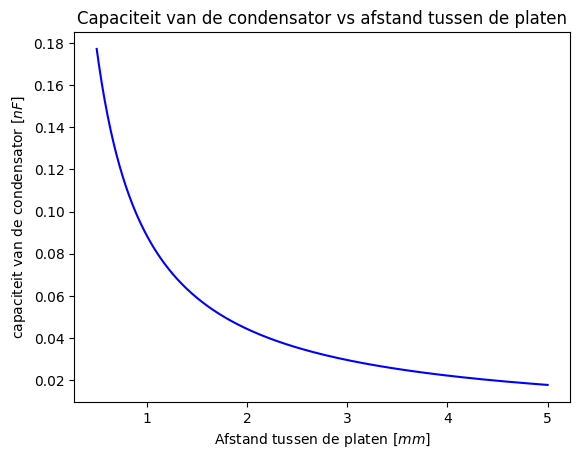

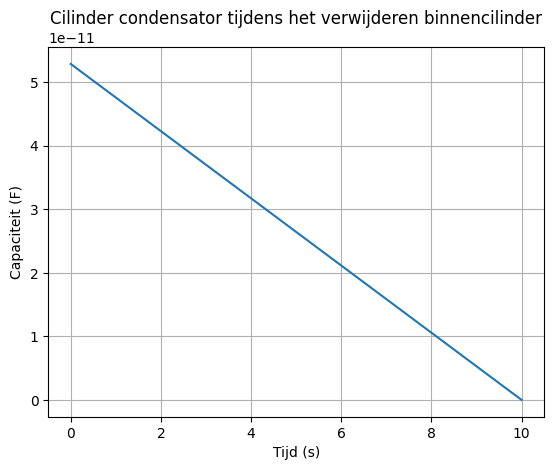

In [25]:
###
###Jouw code hier###
###

Oppervlakte = 0.1 * 0.1
epsilon_r = 1.0006

d = np.linspace(0.5, 5, 451)

capaciteit = vlakkeplaat(Oppervlakte, epsilon_r, d / 1000) * 1e9

plt.figure()
plt.plot(d, capaciteit, color='b')
plt.xlabel(r"Afstand tussen de platen [$mm$]")
plt.ylabel(r"capaciteit van de condensator [$nF$]")
plt.title("Capaciteit van de condensator vs afstand tussen de platen")
plt.show()

r_binnen = 4.5e-3
r_buiten = 5.0e-3
L_totaal = 0.10

t = np.linspace(0, 10, 100)
L = L_totaal * (1 - t / 10)

C_cilinder = cilinder(1.0006, r_binnen, r_buiten, L)

plt.figure()
plt.plot(t, C_cilinder)
plt.xlabel('Tijd (s)')
plt.ylabel('Capaciteit (F)')
plt.title('Cilinder condensator tijdens het verwijderen binnencilinder')
plt.grid(True)
plt.show()



## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![Alt](figures/Meeting1.jpeg "analyse: ideeen")

![Alt](figures/Eind_schets_weegschaal.jpeg "analyse: ideeen")

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [26]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

import numpy as np

def vlakkeplaat(A, epsilon_r, d):
    epsilon0 = 8.854e-12
    C = epsilon0 * epsilon_r * A / d
    return C

def bereken_voltage(R,C,f,A):
    V = C * R * A * 2 * np.pi * f
    return V

def bereken_capaciteit(V, R, f, A):
    C = V / (R * A * 2 * np.pi * f)
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.
# Test

In [27]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie

epsilon_r_lucht = 1.0006

epsilon_r_spons = 2.1

A_spons = 0.025**2

A = 0.1**2

d_0 = 6e-3

g = 9.81

def capasiteit_ont_2(m, k, b):
    C = (epsilon0 * (4 * epsilon_r_spons * A_spons + epsilon_r_lucht * (A - 4 * A_spons)))/(d_0 - g * m / k)
    return C * 1e12 + b


### Maak hier je plot

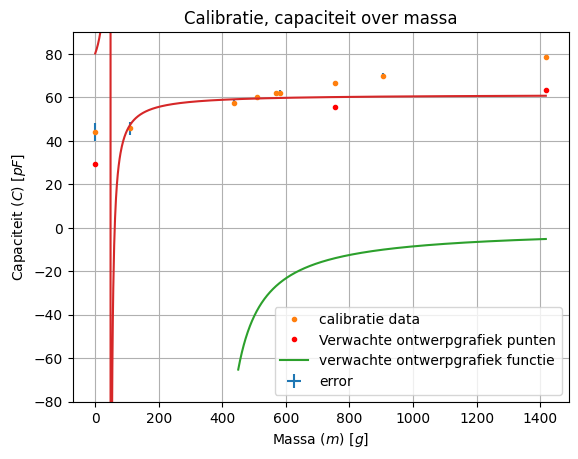

In [28]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.

# Bij de volgende berekeningen gaan wij ervanuit dat de afstand tussen de platen van de condensator 
# liniear afneemt naarmaten het gewicht liniear toeneemt

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def ontwerpfunctie(m, k):
    C = A * epsilon0 * epsilon_r / (d_0 - g * m / k)
    return C * 1e12

m = np.array([0., 754., 1418.])

m_test = np.linspace(450, m[2], 1000)

d = np.array([3, 1.6, 1.4]) / 1000

A = 0.01

Amplitude = 8

f = 100e3

R = 1000

epsilon_r = 1

epsilon0 = 8.854e-12

d_0 = 6 / 1000

g = 9.81

C = vlakkeplaat(A, epsilon_r, d)

V = bereken_voltage(R, C, f, Amplitude) * 1000

x_functie_fit = np.linspace(min(m), max(m), 1000)

massa_array = np.array([0,109,436,508,570,581,754,907,1418])
capaciteit_array = np.array([44,45.7,57.6,60.1,61.8,62.2,66.5,70,78.7])
u_massa = 0.5
u_capaciteit = np.array([4,3,1,1,1,1,1,1,1])

values, cov = curve_fit(capasiteit_ont_2, massa_array, capaciteit_array)

plt.figure()
plt.errorbar(massa_array,capaciteit_array,xerr=u_massa,yerr=u_capaciteit, label="error", linestyle= "None")
plt.plot(massa_array,capaciteit_array,".", label="calibratie data")
plt.plot(m, C * 1e12, 'r.', label="Verwachte ontwerpgrafiek punten")
plt.plot(m_test, ontwerpfunctie(m_test / 1000, k = 600), label="verwachte ontwerpgrafiek functie")
plt.plot(x_functie_fit, capasiteit_ont_2(x_functie_fit, values[0], values[1]))
plt.title("Calibratie, capaciteit over massa")
plt.xlabel(r"Massa ($m$) [$g$]")
plt.ylabel(r"Capaciteit ($C$) [$pF$]")
plt.ylim(-80, 90)
plt.legend()
plt.grid()
plt.show()


##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

(1) Schets van de opstelling:

![Alt](figures/Schets_meetopstelling.jpeg "analyse: ideeen")

(2)

We kunnen de capaciteit berekenen door de capaciteit van alle individuele stukjes bij elkaar op te tellen. Oftewel we beschouwen de delen waar de sponsen zitten als een apparte condensator:

$$ C = 4C_{spons} + C_{lucht} $$

Nu schrijven we $C_{spons}$ en $C_{lucht}$ uit met de eerder gebruikte formules:

$$ C = 4\frac{\epsilon_{0}\epsilon_{r \space spons}A_{spons}}{d} + \frac{\epsilon_{0}\epsilon_{r \space lucht}(A - 4A_{spons})}{d} $$

Dit schrijven we om naar:

$$ C = \frac{\epsilon_{0}}{d}(4\epsilon_{r \space spons}A_{spons} + \epsilon_{r \space lucht}(A - 4A_{spons})) $$

Nu beschouwen we de spons als een veer met een veerconstante om de volgende vergelijking te krijgen:


$$ C = \frac{\epsilon_{0}}{d_0 - \frac{g}{k}m}(4\epsilon_{r \space spons}A_{spons} + \epsilon_{r \space lucht}(A - 4A_{spons})) $$

(3) zie bovenstaande code

(4) zie bovenstaande code

(5)

Bij de verwachte ontwerp gefiek zien wij dat hij erg ver onder de daadwerkelijke waardes zit. Dit was ook het geval bij de analytische plotting van de grafiek totdat we een sistematische fout toe hebben gevoegd. Nu nog steeds klopt de functie fit van de gegeven functie niet met de daadwerkelijke kalibratie waardes. Dit komt hoogst waarschijnlijk door het feit dat een spons niet hetzelfde verband heeft als een veer wanneer je deze indrukt.




#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [29]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons| 0.065 |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

(1)

De wet van Guass zegt het volgende:

$$ \mathbf{\nabla} \cdot \mathbf{E} = \frac{\rho}{\epsilon_{0}} $$

We kunnen de ladingsdichtheid in een vrije en gebonden component opplitsen:

$$ \rho = \rho_{free} + \rho_{bound} $$

Nu schrijven we de wet van Guass om naar:

$$ \epsilon_{0}\mathbf{\nabla} \cdot \mathbf{E} = \rho_{free} + \rho_{bound} $$

We weten dat $\rho_{bound}$ te schrijven is als:

$$ \rho_{bound} = -\mathbf{\nabla} \cdot \mathbf{P} $$

Nu nemen we dit mee in wet van Guass en schrijven we het om naar:

$$ \mathbf{\nabla} \cdot (\epsilon_{0}\mathbf{E} + \mathbf{P}) = \rho_{free} $$

Nu deffineren we het $\mathbf{D}$-veld als het volgende:

$$ \mathbf{D} = \epsilon_{0}\mathbf{E} + \mathbf{P} $$

En dan krijgen we de volgende relatie:

$$ \mathbf{\nabla} \cdot \mathbf{D} = \rho_{free} $$

(2)

Om een uitdrukking van het elektrisch veld in termen van het $\mathbf{D}$-veld te krijgen schrijven we het volgende om:

$$ \mathbf{D} = \epsilon_{0}\mathbf{E} + \mathbf{P} $$

Naar:

$$ \mathbf{E} = \frac{\mathbf{D} - \mathbf{P}}{\epsilon_{0}} $$

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [30]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(P, D):
    return (D - P) / epsilon0

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

*Antwoord vraag 7, de laatste.*

Het feit dat er stukjes spons tussen de condensator platen zitten zal vast wel wat effect hebben op het feit dat onze verwachte kalibratie grafiek niet overeenkomt met de daadwerkelijke kalibratie grafiek, maar dit effect is maar klein. Er is een veel grote fout in onze functie, namelijk dat je een spons niet als een veer kan beschouwen om hiermee verder te rekenen. Hoe een spons zich daadwerkelijk gedragd wanneer je deze indrukt is voor ons ook niet goed bekend. Hierdoor is opdracht 6 niet erg goed afgerond.